# CityTaste (Ottawa) — Notebook Data Pipeline + EDA + Baseline Recommender

**Objectif du notebook :**  
1) Charger et vérifier les données `ottawa_places_from_osm.csv` (OpenStreetMap / Overpass).  
2) Nettoyer et préparer un dataset **MVP** (`ottawa_places_clean.csv`).  
3) Construire une base **SQLite** (`citytaste_ottawa.db`).  
4) Implémenter une recommandation **baseline** (scoring simple) : proximité + match cuisine + complétude des infos.  

> **Attribution (obligatoire) :** données © OpenStreetMap contributors (ODbL).

In [3]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import numpy as np
import sqlite3
import math
import matplotlib.pyplot as plt


# 1) Paths & Project config

def get_project_root(marker: str = "data") -> Path:
    """
    Return the project root (folder that contains /data).
    Works even if you run the notebook from /notebooks.
    """
    here = Path.cwd().resolve()
    for p in [here] + list(here.parents):
        if (p / marker).exists():
            return p
    # fallback (rare) : current working directory
    return here


PROJECT_ROOT = get_project_root()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = RAW_DIR / "ottawa_places_from_osm.csv"
CLEAN_CSV_PATH = PROCESSED_DIR / "ottawa_places_clean.csv"
DB_PATH = PROCESSED_DIR / "citytaste_ottawa.db"


# 2) Quick sanity checks

def print_paths_summary() -> None:
    print("PROJECT_ROOT :", PROJECT_ROOT)
    print("RAW_PATH     :", RAW_PATH, "| exists:", RAW_PATH.exists())
    print("CLEAN_CSV    :", CLEAN_CSV_PATH)
    print("DB_PATH      :", DB_PATH)
    print("PROCESSED_DIR:", PROCESSED_DIR, "| exists:", PROCESSED_DIR.exists())


print_paths_summary()

PROJECT_ROOT : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste
RAW_PATH     : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\raw\ottawa_places_from_osm.csv | exists: True
CLEAN_CSV    : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\ottawa_places_clean.csv
DB_PATH      : C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\citytaste_ottawa.db
PROCESSED_DIR: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed | exists: True


## 1) Charger le CSV et inspection rapide

In [4]:
if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable: {RAW_PATH}\n"
        
    )

df_raw = pd.read_csv(RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1104, 21)


,osm_type,osm_id,name,place_type,amenity,tourism,cuisine,lat,lon,addr_housenumber,...,addr_city,addr_postcode,address,phone,website,opening_hours,wheelchair,brand,source,tags_json
0,relation,14526702,Les Suites Hotel,hotel,NaN,hotel,NaN,45.426134,-75.688731,130,...,Ottawa,K1N 9M9,130 Besserer Street,+1 613 232 2000,https://www.les-suites.com/,NaN,yes,NaN,City of Ottawa,"{""@id"": ""relation/14526702"", ""addr:city"": ""Ott..."
1,way,31813259,Embassy Hotel and Suites,hotel,NaN,hotel,NaN,45.419679,-75.688818,25,...,Ottawa,K2P 1J2,25 Cartier Street,NaN,NaN,NaN,NaN,NaN,NaN,"{""@id"": ""way/31813259"", ""addr:housenumber"": ""2..."
2,way,31813278,The Business Inn & Suites,hotel,NaN,hotel,NaN,45.416980,-75.689237,180,...,Ottawa,NaN,180 MacLaren Street,+1-613-232-1121,https://www.thebusinessinn.com/,NaN,NaN,NaN,City of Ottawa,"{""@id"": ""way/31813278"", ""addr:housenumber"": ""1..."
3,way,46016942,Ottawa Jail Hostel,hostel,NaN,hostel,NaN,45.425111,-75.688451,75,...,Ottawa,K1N 7B9,75 Nicholas Street,NaN,https://saintlo.ca/en/hostels/ottawa-jail/,NaN,NaN,NaN,NaN,"{""@id"": ""way/46016942"", ""addr:housenumber"": ""7..."
4,way,55411730,Sonder Rideau Apartments Downtown,hotel,NaN,hotel,NaN,45.420741,-75.694605,161,...,Ottawa,K1P 5J2,161 Laurier Avenue West,NaN,NaN,NaN,NaN,NaN,NaN,"{""@id"": ""way/55411730"", ""addr:housename"": ""Res..."


In [5]:
print("Colonnes:", list(df_raw.columns))

Colonnes: ['osm_type', 'osm_id', 'name', 'place_type', 'amenity', 'tourism', 'cuisine', 'lat', 'lon', 'addr_housenumber', 'addr_street', 'addr_city', 'addr_postcode', 'address', 'phone', 'website', 'opening_hours', 'wheelchair', 'brand', 'source', 'tags_json']


### Valeurs manquantes (Top 15)

In [6]:
missing_pct = (df_raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.head(15)

tourism             91.4
wheelchair          88.9
brand               84.2
opening_hours       77.5
addr_postcode       77.4
phone               72.3
website             65.3
source              62.5
cuisine             32.0
amenity              8.6
addr_housenumber     6.6
addr_street          6.3
address              6.2
name                 0.1
place_type           0.0
dtype: float64

### Répartition `place_type`

In [7]:
df_raw["place_type"].value_counts(dropna=False)

place_type
restaurant     1009
hotel            66
guest_house      16
motel            10
hostel            3
Name: count, dtype: int64

## 2) Nettoyage minimal (MVP)
Règles V1 :
- Supprimer doublons par `osm_id`
- Forcer `lat/lon` en numérique, supprimer lignes sans coordonnées
- Normaliser `place_type`
- Garder uniquement : `restaurant`, `hotel`, `motel`, `guest_house`, `hostel`

In [8]:
df = df_raw.drop_duplicates(subset=["osm_type", "osm_id"]).copy()

df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df = df.dropna(subset=["lat", "lon"]).copy()

df["place_type"] = df["place_type"].fillna("other").astype(str).str.strip().str.lower()
allowed = {"restaurant", "hotel", "motel", "guest_house", "hostel"}
df = df[df["place_type"].isin(allowed)].copy()

print("Après nettoyage:", df.shape)
df["place_type"].value_counts()

Après nettoyage: (1104, 21)


place_type
restaurant     1009
hotel            66
guest_house      16
motel            10
hostel            3
Name: count, dtype: int64

## 3) Feature Engineering
Features utiles :
- `cuisine_list` : séparation `italian;pizza` → liste
- `info_score` : présence de `website`, `phone`, `opening_hours` (0 à 3)

In [9]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

df["cuisine_norm"] = df["cuisine"].apply(normalize_text)
df["cuisine_list"] = df["cuisine_norm"].apply(lambda s: [c.strip() for c in s.split(";") if c.strip()])

df["has_website"] = df["website"].notna() & (df["website"].astype(str).str.strip() != "")
df["has_phone"] = df["phone"].notna() & (df["phone"].astype(str).str.strip() != "")
df["has_opening_hours"] = df["opening_hours"].notna() & (df["opening_hours"].astype(str).str.strip() != "")
df["info_score"] = df["has_website"].astype(int) + df["has_phone"].astype(int) + df["has_opening_hours"].astype(int)

df[["name","place_type","cuisine","info_score","address"]].head(10)

,name,place_type,cuisine,info_score,address
0,Les Suites Hotel,hotel,NaN,2,130 Besserer Street
1,Embassy Hotel and Suites,hotel,NaN,0,25 Cartier Street
2,The Business Inn & Suites,hotel,NaN,2,180 MacLaren Street
3,Ottawa Jail Hostel,hostel,NaN,1,75 Nicholas Street
4,Sonder Rideau Apartments Downtown,hotel,NaN,0,161 Laurier Avenue West
5,Hampton Inn by Hilton Ottawa,hotel,NaN,2,100 Coventry Road
6,Perkins,restaurant,american,1,1130 St-Laurent Boulevard
7,Capital Hill Hotel & Suites,hotel,NaN,1,88 Albert Street
8,St-Hubert,restaurant,chicken;barbecue,1,1754 St-Laurent Boulevard
9,Senpai,restaurant,sushi,0,2280 Carling Avenue


## 4) Mini-EDA (qualité + diversité)
### 4.1 Répartition restaurants vs hébergements

In [10]:
counts = df["place_type"].value_counts()
counts

place_type
restaurant     1009
hotel            66
guest_house      16
motel            10
hostel            3
Name: count, dtype: int64

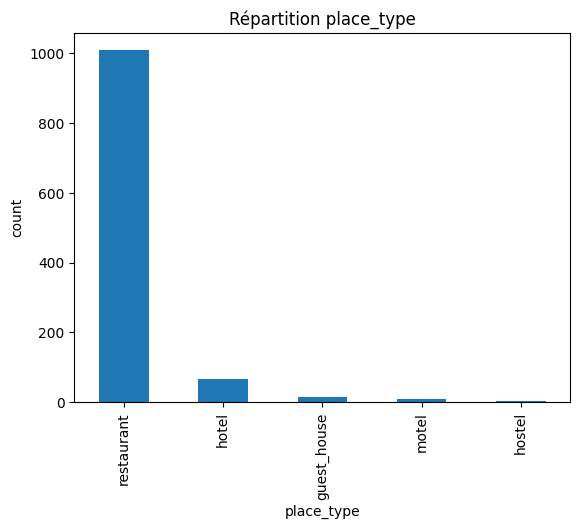

In [11]:
plt.figure()
counts.plot(kind="bar")
plt.title("Répartition place_type")
plt.xlabel("place_type")
plt.ylabel("count")
plt.show()

### 4.2 Complétude de quelques champs clés

In [12]:
key_fields = ["cuisine","address","website","phone","opening_hours","wheelchair"]
key_missing = (df[key_fields].isna().mean()*100).round(1).sort_values(ascending=False)
key_missing

wheelchair       88.9
opening_hours    77.5
phone            72.3
website          65.3
cuisine          32.0
address           6.2
dtype: float64

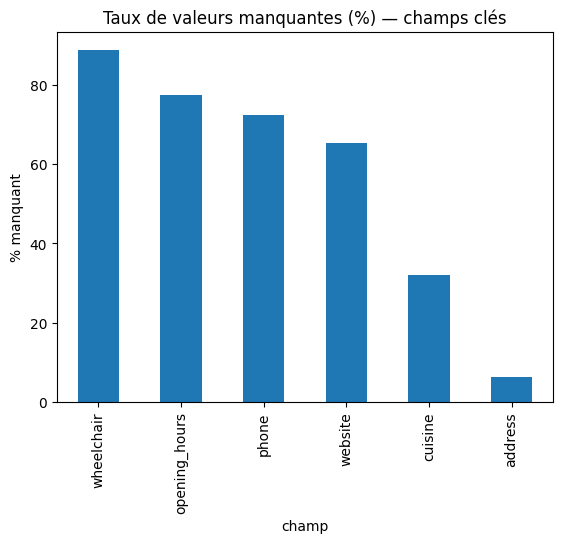

In [13]:
plt.figure()
key_missing.plot(kind="bar")
plt.title("Taux de valeurs manquantes (%) — champs clés")
plt.xlabel("champ")
plt.ylabel("% manquant")
plt.show()

### 4.3 Top cuisines (restaurants)

In [14]:
restaurants = df[df["place_type"]=="restaurant"].copy()
c_list = restaurants["cuisine_list"].explode()
c_list = c_list[c_list.notna() & (c_list.astype(str).str.strip()!="")]
top_cuisines = c_list.value_counts().head(15)
top_cuisines

cuisine_list
chinese       74
indian        72
pizza         67
italian       50
vietnamese    47
thai          31
sushi         31
breakfast     30
mexican       28
burger        24
seafood       23
chicken       22
japanese      21
asian         21
american      19
Name: count, dtype: int64

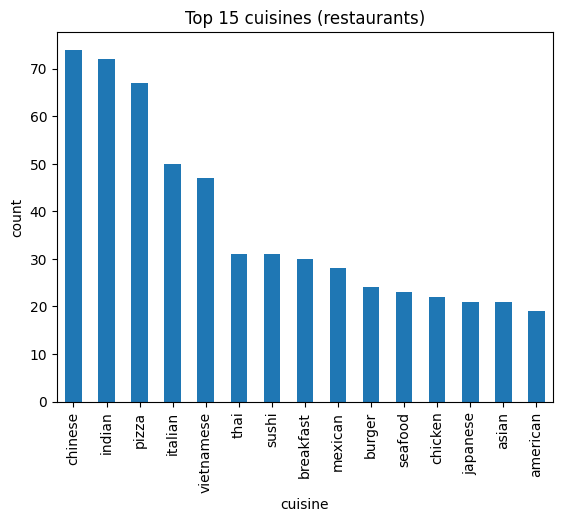

In [15]:
plt.figure()
top_cuisines.plot(kind="bar")
plt.title("Top 15 cuisines (restaurants)")
plt.xlabel("cuisine")
plt.ylabel("count")
plt.show()

## 5) Sauvegarde du dataset nettoyé

In [16]:
df.to_csv(CLEAN_CSV_PATH, index=False)
print("Sauvegardé:", CLEAN_CSV_PATH)

Sauvegardé: C:\Users\Innocent\OneDrive\Bureau\@ProgrammeAI_cours_session_04\Projet Capstone en IA\CityTaste\data\processed\ottawa_places_clean.csv


## 6) Création DB SQLite

In [17]:
if DB_PATH.exists():
    DB_PATH.unlink()

con = sqlite3.connect(DB_PATH)
df.to_sql("places", con, index=False, if_exists="replace")

cur = con.cursor()
cur.execute("CREATE INDEX IF NOT EXISTS idx_places_type ON places(place_type);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_places_name ON places(name);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_places_lat_lon ON places(lat, lon);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_places_cuisine ON places(cuisine);")
con.commit()

total = cur.execute("SELECT COUNT(*) FROM places;").fetchone()[0]
by_type = cur.execute("SELECT place_type, COUNT(*) FROM places GROUP BY place_type ORDER BY COUNT(*) DESC;").fetchall()
con.close()

print("DB créée:", DB_PATH)
print("Total rows:", total)
print("Répartition:", by_type)

ProgrammingError: Error binding parameter 23: type 'list' is not supported

## 7) Baseline Recommender (scoring simple)
Score V1 :
- **0.60** × proximité
- **0.25** × match cuisine (si fourni)
- **0.15** × complétude (`info_score` normalisé)

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1 = math.radians(lat1)
    p2 = math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)

    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

def recommend_baseline(df_places, user_lat, user_lon, place_type="restaurant",
                       cuisine=None, radius_km=5.0, top_k=10):
    place_type = place_type.strip().lower()
    cuisine_norm = cuisine.strip().lower() if cuisine else None

    d = df_places[df_places["place_type"] == place_type].copy()

    d["distance_km"] = d.apply(lambda r: haversine_km(user_lat, user_lon, r["lat"], r["lon"]), axis=1)
    d = d[d["distance_km"] <= radius_km].copy()

    if cuisine_norm:
        d["cuisine_match"] = d["cuisine_list"].apply(lambda lst: cuisine_norm in lst if isinstance(lst, list) else False).astype(int)
    else:
        d["cuisine_match"] = 0

    d["distance_score"] = 1 / (1 + d["distance_km"])
    d["info_score_norm"] = d["info_score"] / 3.0

    d["final_score"] = (
        0.60 * d["distance_score"]
        + 0.25 * d["cuisine_match"]
        + 0.15 * d["info_score_norm"]
    )

    def explain(row):
        parts = [f"proche ({row['distance_km']:.1f} km)"]
        if row["cuisine_match"] == 1 and cuisine_norm:
            parts.append(f"cuisine match ({cuisine_norm})")
        if row["info_score"] >= 2:
            parts.append("infos complètes (site/tél/horaires)")
        return " + ".join(parts)

    d["explanation"] = d.apply(explain, axis=1)

    out_cols = ["name","place_type","cuisine","distance_km","address","website","final_score","explanation"]
    return d.sort_values("final_score", ascending=False).head(top_k)[out_cols]

# Test: centre-ville Ottawa
recommend_baseline(df, user_lat=45.4215, user_lon=-75.6972,
                   place_type="restaurant", cuisine="italian", radius_km=3, top_k=10)

## 8) Notes “gouvernance” 
- **Risque principal : complétude** (valeurs manquantes) sur `website`, `phone`, `opening_hours`, `wheelchair`, et parfois `cuisine`.
- **Mesure V1 :** `info_score` + transparence (“donnée manquante”) + diversité Top-N.
- **Reproductibilité :** conserver un snapshot daté (CSV + DB) + scripts de préparation.